In [178]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# npz = np.load(Path("data/Gasecki/Gasecki_data_corr_total.npz"), allow_pickle=True)
# gasecki_e_xy = npz["E_xy"]

# npz = np.load(Path("data/Sobieski/Sobieski_data_corr_total.npz"), allow_pickle=True)
# sobieski_e_xy = npz["E_xy"]

# npz = np.load(Path("data/Matka_Boska/Matka_Boska_data_corr_total_Cu.npz"), allow_pickle=True)
# matka_boska_e_xy = npz["E_xy"]

npz = np.load(Path("data/Blank_PcbCu/GEM_Cr_PBS1_Blank_PcbCu_ArCO2_75_25_Gain_35_Thr_35_HV_3640_Xray_50kV_04mA_part_001_GainCorr.pcap.dat.npz"), allow_pickle=True)
cu_e_xy = npz["E_xy"]


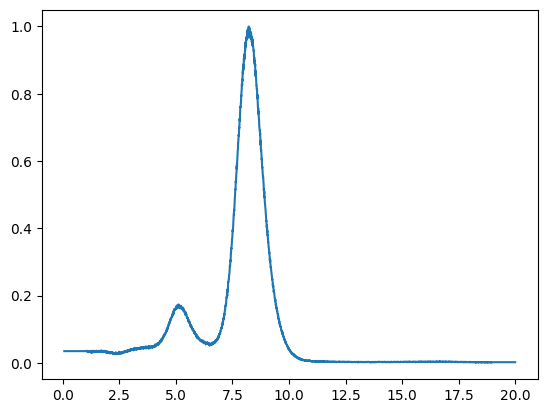

In [179]:
from src.DataPreprocessor import DataPreprocessor

peaks_cu = [720, 985, 1594, 2068]
energies_cu = [3.692, 5.088, 8.046, 10.551]

signal = (cu_e_xy[50, 50]/np.max(cu_e_xy[50, 50]))

energy, spectrum = DataPreprocessor.get_processed_spectrum( np.average(cu_e_xy, axis=(0, 1)), peaks_cu, energies_cu)

plt.plot(energy, spectrum)

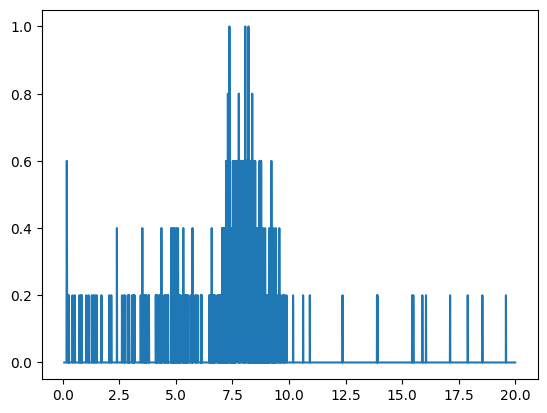

In [180]:
plt.plot(energy, signal)

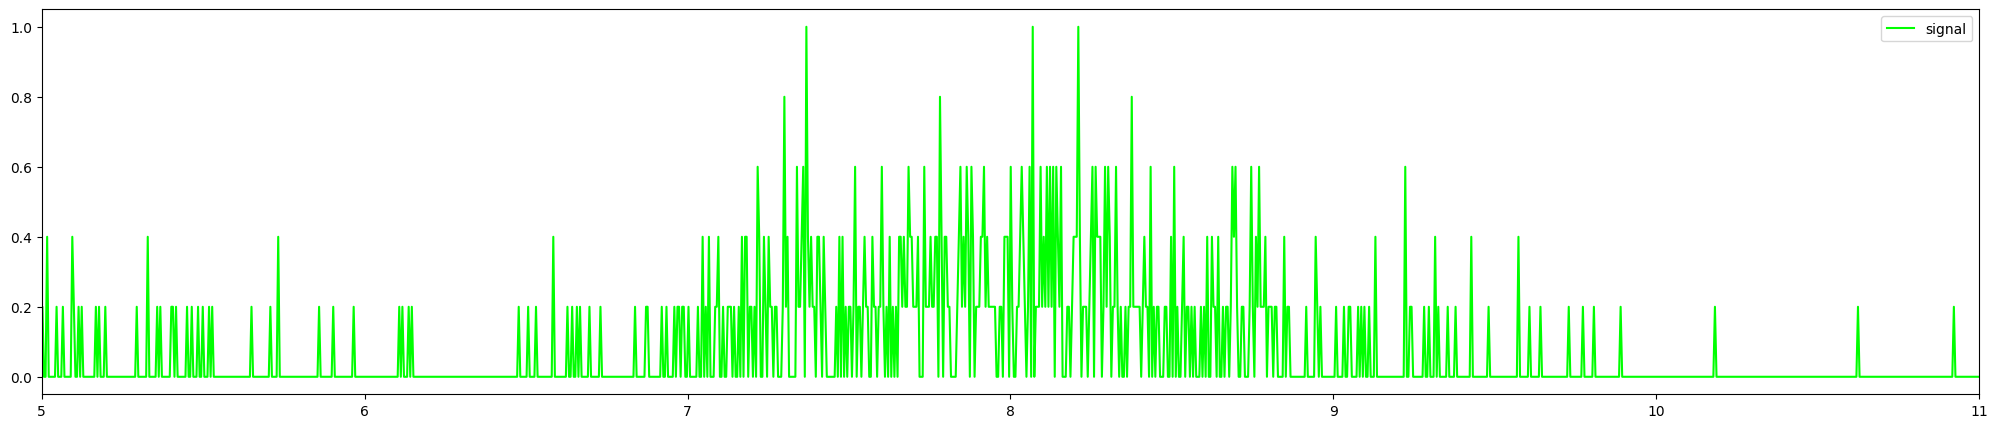

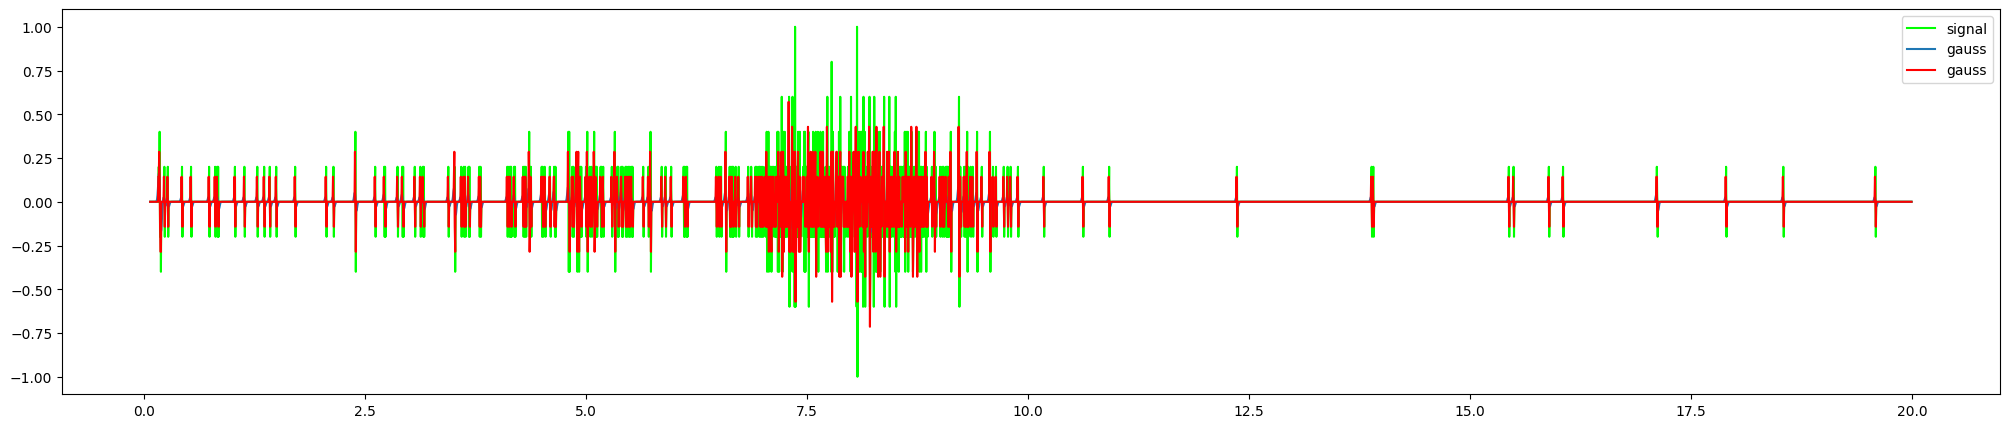

In [277]:
from scipy.ndimage import gaussian_filter1d, maximum_filter1d, uniform_filter1d, median_filter
from scipy.signal._savitzky_golay import savgol_filter
import fastkde
import math


width = 2

power = 1
degree = 1
# radius = 8
r = [1000, 2000]
plt.figure(figsize=(25, 5))

import scipy.signal

def nonlinearDiffusionFilter1D(signal: np.ndarray, iterations=10, lamb=1.0, tau=0.125, signal_seq=None):
    """
    Execute nonlinear, isotropic, smoothing filter on a 1D signal.
    The method is based on the 1990 paper by Perona and Malik.
    This smoothing method uses diffusion that preserves edges.
    """

    def computeUpdate(u: np.ndarray, g: np.ndarray):
        """
        Compute the update for the next iteration using the spatial derivatives.
        """
        update = np.zeros(u.shape, dtype=float)
        u = np.pad(u, pad_width=1, mode='constant')
        g = np.pad(g, pad_width=1, mode='constant')

        for i in range(1, len(u) - 1):
            g_p = math.sqrt(g[i + 1] * g[i]) if i < len(u) - 2 else 0
            g_n = math.sqrt(g[i - 1] * g[i]) if i > 1 else 0

            ux0 = g_p * (u[i + 1] - u[i])
            ux1 = -g_n * (u[i] - u[i - 1])

            update[i - 1] = ux0 + ux1
        return update

    def computeDiffusivity(u: np.ndarray, lamb: float):
        """
        Compute the nonlinear, gradient-derived diffusivity for 1D signals.
        """
        grad_u = np.gradient(u)
        gradm2 = grad_u ** 2
        g = 1.0 / np.sqrt(1.0 + gradm2 / (lamb * lamb))
        return g

    u = np.copy(signal)
    if signal_seq is not None:
        signal_seq.append(np.copy(u))

    for i in range(iterations):
        print(f"Iteration: {i + 1}/{iterations}")
        g = computeDiffusivity(u, lamb)
        update = computeUpdate(u, g)
        u = u + tau * update
        if signal_seq is not None:
            signal_seq.append(np.copy(u))

    return u




# temp = gaussian_filter1d(signal, 8, mode="nearest")
# plt.plot(np.exp(gaussian_filter1d(np.log(signal + 10e-3), width)) / np.max(np.exp(gaussian_filter1d(np.log(signal + 10e-3), width))), label="log")
plt.plot(energy, np.power(signal, power)  , label="signal", color="lime")
# plt.plot(energy, np.power(gaussian_filter1d(maximum_filter1d(signal, width), width) / (np.max(gaussian_filter1d(maximum_filter1d(signal, width), width)) + 10e-5), power), label="gauss")
# plt.plot(energy, np.power(savgol_filter(signal, width, degree) / (np.max(savgol_filter(signal, width, degree)) + 10e-5), 2), label="savgol", color="red")
plt.xlim((5, 11))
plt.legend()

plt.figure(figsize=(25, 5))
plt.plot(energy[:-1], np.diff(np.power(signal, 1)), label="signal", color="lime")
plt.plot(energy[:-1], np.diff(np.power(gaussian_filter1d(signal, width) / (np.max(gaussian_filter1d(signal, width)) + 10e-5), 1)), label="gauss")
plt.plot(energy[:-1], np.diff(np.power(savgol_filter(signal, width, degree) / (np.max(savgol_filter(signal, width, degree)) + 10e-5), 1)), label="gauss", color="red")
plt.legend()



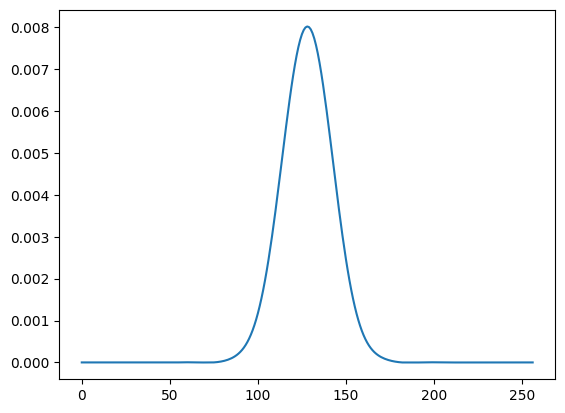

In [249]:
import numpy as np
import fastkde
import matplotlib.pyplot as plt

#Generate two random variables dataset (representing 100,000 pairs of datapoints)
N = int(1e5)
x = 50*np.random.normal(size=N) + 0.1
y = 0.01*np.random.normal(size=N) - 300

#Do the self-consistent density estimate
PDF, axes = fastkde.pdf(x)

plt.plot(PDF);

In [ ]:
pimport numpy as np
from .src.SelfOrganizingMap import SelfOrganizingMap

som = SelfOrganizingMap(4096, (3, 3))


In [ ]:
def get_som_clustered_labels(e_xy, epochs=10, map_size=(3,3), learning_rate=0.1, sigma_neigh=0.5, sigma_decay=0.5):
    e_xy_flat= e_xy.reshape(-1, e_xy.shape[-1])
    e_xy_max_channel_counts = np.max(np.abs(e_xy_flat), axis=1, keepdims=True)
    e_xy_flat_normalized = e_xy_flat/ e_xy_max_channel_counts
    som = SelfOrganizingMap(input_size=e_xy.shape[-1], map_size=map_size, learning_rate=learning_rate, sigma_neigh=sigma_neigh, sigma_decay=sigma_decay)
    som.train(e_xy_flat_normalized, epochs)
    bmus = [[som.find_bmu(e_xy_flat_normalized[i * e_xy.shape[1] + j]) for j in range(e_xy.shape[1])] for i in range(e_xy.shape[0])]
    labels = [[bmu[0] * map_size[1] + bmu[1] for bmu in bmus_row] for bmus_row in bmus]
    return labels



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import gc
gc.collect()

e_xy_flat= e_xy.reshape(-1, e_xy.shape[-1])
e_xy_max_channel_counts = np.max(np.abs(e_xy_flat), axis=1, keepdims=True)
e_xy_flat_normalized = e_xy_flat/ e_xy_max_channel_counts

clusterable_embedding = umap.UMAP(
    n_neighbors=30,
    min_dist=0.0,
    n_components=1,
    m
).fit_transform(e_xy_flat_normalized)